# Panel models

Three claims to nail statistically:

1. Cross-line CJTP differences are systematic, not noise — they survive
   line and time fixed effects.
2. Lines with modern signaling (CBTC: L, 7) recovered post-pandemic at
   a different pace than the rest.
3. Service-area income, by itself, doesn't drive service quality —
   once line fixed effects are in, the income coefficient should fade.

Data is a line × month panel, 2015–2026, peak hours only. Standard
errors clustered at the line level.

In [1]:
import sys
sys.path.append("../code")

import pandas as pd
import numpy as np
from pathlib import Path
from utils import MTA_COLORS, MAIN_LINES

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RAW / "cjm_2015_present.csv", parse_dates=["month"])
df.columns = (
    df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
)
df = df[df["line"].isin(MAIN_LINES) & (df["line"] != "S 42nd")]
df = df[df["period"] == "peak"].copy()
df["year"] = df["month"].dt.year

CBTC_LINES = ["L", "7"]
df["cbtc"] = df["line"].isin(CBTC_LINES).astype(int)

df["post_pandemic"] = (df["month"] >= "2022-01-01").astype(int)

df = df.rename(columns={"customer_journey_time_performance": "cjtp"})
df = df[["line", "month", "year", "cjtp", "cbtc", "post_pandemic", "num_passengers"]].dropna()

print("panel shape:", df.shape)
print("lines:", df["line"].nunique())
print("months:", df["month"].nunique())
print("date range:", df["month"].min().date(), "to", df["month"].max().date())
print("\nCBTC distribution:")
print(df.groupby("cbtc").size())

panel shape: (2466, 7)
lines: 21
months: 135
date range: 2015-01-01 to 2026-03-01

CBTC distribution:
cbtc
0    2222
1     244
dtype: int64


In [2]:
line_income = {
    "1": 119004, "2": 106067, "3": 119129, "4": 107087, "5": 100899,
    "6": 112836, "7": 93520,
    "A": 107219, "B": 94571, "C": 114552, "D": 87877, "E": 117211,
    "F": 113510, "G": 128909,
    "JZ": 91953, "L": 110748, "M": 104426,
    "N": 129348, "Q": 124814, "R": 122976, "W": 125784,
}

df["income"] = df["line"].map(line_income)
df["income_10k"] = df["income"] / 10000

panel = df.set_index(["line", "month"]).sort_index()
print(panel.head())
print()
print("income_10k stats:", panel["income_10k"].describe()[["min", "max", "mean"]].round(2).to_dict())

                 year      cjtp  cbtc  post_pandemic  num_passengers  income  \
line month                                                                     
1    2015-01-01  2015  0.887746     0              0       5170116.8  119004   
     2015-02-01  2015  0.849256     0              0       5960062.2  119004   
     2015-03-01  2015  0.874342     0              0       7678261.6  119004   
     2015-04-01  2015  0.913988     0              0       6880455.0  119004   
     2015-05-01  2015  0.908361     0              0       6373169.3  119004   

                 income_10k  
line month                   
1    2015-01-01     11.9004  
     2015-02-01     11.9004  
     2015-03-01     11.9004  
     2015-04-01     11.9004  
     2015-05-01     11.9004  

income_10k stats: {'min': 8.79, 'max': 12.93, 'mean': 11.09}


In [3]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

X1 = sm.add_constant(panel[["income_10k"]])
y = panel["cjtp"]

model_1 = sm.OLS(y, X1).fit(cov_type="cluster", cov_kwds={"groups": panel.index.get_level_values("line")})
print(model_1.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7319      0.082      8.980      0.000       0.572       0.892
income_10k     0.0099      0.007      1.342      0.180      -0.005       0.024


In [4]:
panel_clean = panel.dropna(subset=["cjtp", "cbtc", "post_pandemic", "income_10k"])

mod_2 = PanelOLS.from_formula(
    "cjtp ~ 1 + EntityEffects + TimeEffects",
    data=panel_clean,
)
res_2 = mod_2.fit(cov_type="clustered", cluster_entity=True)
print(res_2)

                          PanelOLS Estimation Summary                           
Dep. Variable:                   cjtp   R-squared:                     -2.22e-16
Estimator:                   PanelOLS   R-squared (Between):              0.0000
No. Observations:                2466   R-squared (Within):               0.0000
Date:                Fri, May 08 2026   R-squared (Overall):              0.0000
Time:                        14:09:04   Log-likelihood                    5647.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                          --
Entities:                          21   P-value                               --
Avg Obs:                       117.43   Distribution:                         --
Min Obs:                       107.00                                           
Max Obs:                       135.00   F-statistic (robust):                 --
                            

In [5]:
mod_3 = PanelOLS.from_formula(
    "cjtp ~ 1 + cbtc:post_pandemic + EntityEffects + TimeEffects",
    data=panel_clean,
)
res_3 = mod_3.fit(cov_type="clustered", cluster_entity=True)
print(res_3)

                          PanelOLS Estimation Summary                           
Dep. Variable:                   cjtp   R-squared:                        0.0003
Estimator:                   PanelOLS   R-squared (Between):              0.0063
No. Observations:                2466   R-squared (Within):               0.0025
Date:                Fri, May 08 2026   R-squared (Overall):              0.0056
Time:                        14:09:35   Log-likelihood                    5647.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.5992
Entities:                          21   P-value                           0.4390
Avg Obs:                       117.43   Distribution:                  F(1,2310)
Min Obs:                       107.00                                           
Max Obs:                       135.00   F-statistic (robust):             0.0261
                            

## CBTC rollout as a staggered treatment

The earlier DiD using a single post-2022 cutoff failed because it
collapsed CBTC adoption — which actually rolled out over a decade —
into a single time point that confounds with pandemic recovery. The
true treatment varies by line: the L was first, completed February
2012; the 7 was second, completed November 2018. All other lines
remain untreated within our sample window.

The model: a two-way fixed effects panel with a treatment dummy that
turns on for each line at its own activation date.

In [6]:
cbtc_rollout = {
    "L": pd.Timestamp("2012-02-01"),
    "7": pd.Timestamp("2018-11-01"),
}

panel_clean = panel_clean.reset_index()
panel_clean["cbtc_active"] = 0
for line, start_date in cbtc_rollout.items():
    mask = (panel_clean["line"] == line) & (panel_clean["month"] >= start_date)
    panel_clean.loc[mask, "cbtc_active"] = 1

panel_clean = panel_clean.set_index(["line", "month"]).sort_index()

print("treatment cell counts:")
print(panel_clean.groupby(["line", "cbtc_active"]).size().unstack(fill_value=0))

treatment cell counts:
cbtc_active    0    1
line                 
1            135    0
2            135    0
3            135    0
4            135    0
5            135    0
6            135    0
7             46   89
A            109    0
B            107    0
C            108    0
D            109    0
E            109    0
F            109    0
G            109    0
JZ           109    0
L              0  109
M            109    0
N            109    0
Q            109    0
R            109    0
W            107    0


In [7]:
mod_4 = PanelOLS.from_formula(
    "cjtp ~ 1 + cbtc_active + EntityEffects + TimeEffects",
    data=panel_clean,
)
res_4 = mod_4.fit(cov_type="clustered", cluster_entity=True)
print(res_4)

                          PanelOLS Estimation Summary                           
Dep. Variable:                   cjtp   R-squared:                        0.0167
Estimator:                   PanelOLS   R-squared (Between):              0.1602
No. Observations:                2466   R-squared (Within):               0.0404
Date:                Fri, May 08 2026   R-squared (Overall):              0.1018
Time:                        14:14:23   Log-likelihood                    5668.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      39.314
Entities:                          21   P-value                           0.0000
Avg Obs:                       117.43   Distribution:                  F(1,2310)
Min Obs:                       107.00                                           
Max Obs:                       135.00   F-statistic (robust):             5.7539
                            

## Event study: validating the CBTC effect

The headline TWFE estimate (cbtc_active = 0.030, p = 0.017) is identified
almost entirely by the 7 train's switch in November 2018. If the 7 was
already trending up before that month — for reasons unrelated to signaling,
like the Hudson Yards station opening — the estimate is contaminated.

An event study lets each pre- and post-treatment month carry its own
coefficient relative to the activation date. Flat pre-trends are the
identifying assumption; a clean jump at month zero is the smoking gun.

Only the 7 contributes pre-period variation; the L is always-treated and
the other 19 lines are never-treated. The 7's pre-period runs Jan 2015
through Oct 2018 (46 months); post-period Nov 2018 through Mar 2026
(89 months).

In [8]:
panel_es = panel_clean.reset_index().copy()

panel_es["months_since_cbtc"] = pd.NA
for line, start_date in cbtc_rollout.items():
    line_mask = panel_es["line"] == line
    months_diff = (
        (panel_es.loc[line_mask, "month"].dt.year - start_date.year) * 12
        + (panel_es.loc[line_mask, "month"].dt.month - start_date.month)
    )
    panel_es.loc[line_mask, "months_since_cbtc"] = months_diff

panel_es["months_since_cbtc"] = pd.to_numeric(panel_es["months_since_cbtc"], errors="coerce")

bins = [
    (-100, -25, "pre_25plus"),
    (-24, -19, "pre_24_19"),
    (-18, -13, "pre_18_13"),
    (-12, -7, "pre_12_7"),
    (-6, -1, "pre_6_1"),
    (0, 5, "post_0_5"),
    (6, 11, "post_6_11"),
    (12, 23, "post_12_23"),
    (24, 47, "post_24_47"),
    (48, 200, "post_48plus"),
]

for lo, hi, name in bins:
    panel_es[f"es_{name}"] = (
        (panel_es["months_since_cbtc"] >= lo)
        & (panel_es["months_since_cbtc"] <= hi)
    ).astype(int)

es_cols = [f"es_{name}" for _, _, name in bins if name != "pre_6_1"]

panel_es = panel_es.set_index(["line", "month"]).sort_index()

formula = "cjtp ~ 1 + " + " + ".join(es_cols) + " + EntityEffects + TimeEffects"
mod_es = PanelOLS.from_formula(formula, data=panel_es)
res_es = mod_es.fit(cov_type="clustered", cluster_entity=True)
print(res_es.summary.tables[1])

                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
Intercept          0.8348     0.0005     1845.1     0.0000      0.8340      0.8357
es_pre_25plus      0.0686     0.0177     3.8881     0.0001      0.0340      0.1033
es_pre_24_19       0.0525     0.0142     3.6983     0.0002      0.0247      0.0804
es_pre_18_13       0.0166     0.0069     2.3898     0.0169      0.0030      0.0302
es_pre_12_7       -0.0243     0.0045    -5.3477     0.0000     -0.0332     -0.0154
es_post_0_5        0.0507     0.0026     19.338     0.0000      0.0455      0.0558
es_post_6_11       0.0605     0.0039     15.437     0.0000      0.0528      0.0681
es_post_12_23      0.0643     0.0057     11.339     0.0000      0.0532      0.0754
es_post_24_47      0.0620     0.0054     11.573     0.0000      0.0515      0.0725
es_p

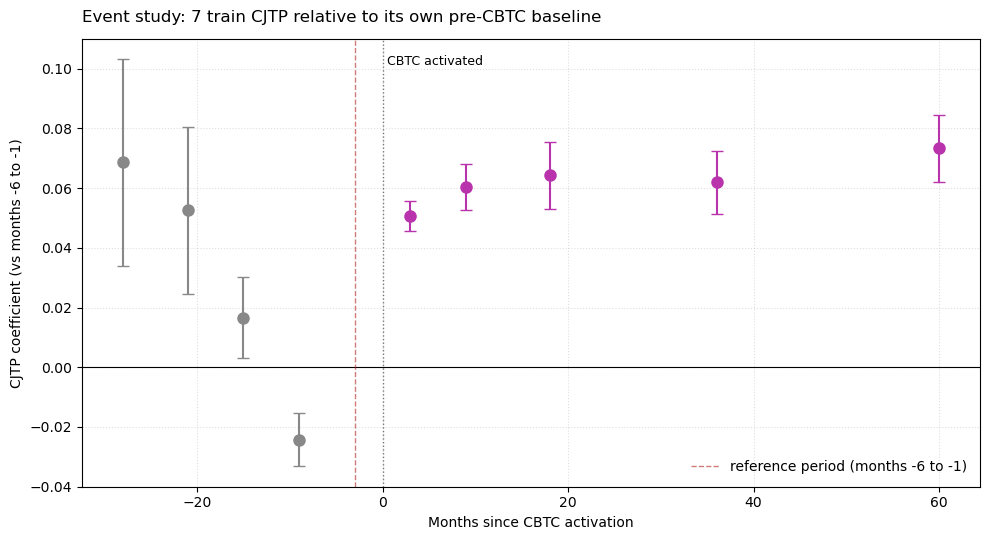

In [9]:
import matplotlib.pyplot as plt
from pathlib import Path

FIGURES = Path("../output/figures")

es_results = res_es.params.drop("Intercept")
es_se = res_es.std_errors.drop("Intercept")

bin_centers = {
    "es_pre_25plus": -28,
    "es_pre_24_19": -21,
    "es_pre_18_13": -15,
    "es_pre_12_7": -9,
    "es_post_0_5": 3,
    "es_post_6_11": 9,
    "es_post_12_23": 18,
    "es_post_24_47": 36,
    "es_post_48plus": 60,
}

fig, ax = plt.subplots(figsize=(10, 5.5))

for var, center in bin_centers.items():
    coef = es_results[var]
    se = es_se[var]
    color = "#B933AD" if center >= 0 else "#888888"
    ax.errorbar(center, coef, yerr=1.96 * se, fmt="o",
                color=color, markersize=8, capsize=4, linewidth=1.5)

ax.axhline(0, color="black", linestyle="-", linewidth=0.8)
ax.axvline(-3, color="firebrick", linestyle="--", linewidth=1, alpha=0.6,
           label="reference period (months -6 to -1)")
ax.axvline(0, color="black", linestyle=":", linewidth=1, alpha=0.5)
ax.text(0.5, ax.get_ylim()[1] * 0.92, "CBTC activated",
        fontsize=9, color="black")

ax.set_xlabel("Months since CBTC activation")
ax.set_ylabel("CJTP coefficient (vs months -6 to -1)")
ax.set_title("Event study: 7 train CJTP relative to its own pre-CBTC baseline",
             loc="left", pad=12)
ax.grid(linestyle=":", alpha=0.4)
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()

fig.savefig(FIGURES / "05_event_study_wip.png", dpi=180, bbox_inches="tight")
fig.savefig(FIGURES / "05_event_study_wip.pdf", bbox_inches="tight")
plt.show()